## Micrograd Demo


In [5]:
import random
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline


In [6]:
def f(x):
  return 3*x**2 - 4*x + 5

In [7]:
f(3.0)

20.0

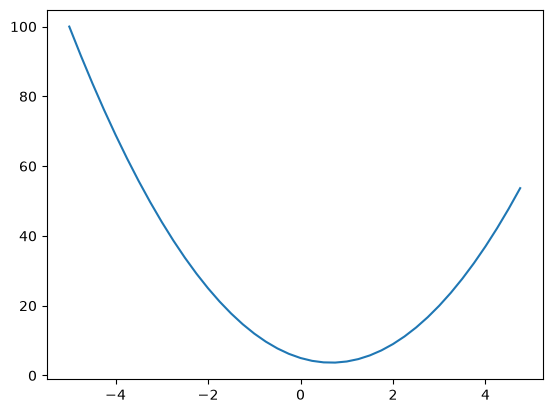

In [8]:
xs = np.arange(-5, 5, 0.25)
ys = f(xs)
plt.plot(xs, ys)

In [94]:
class Value:
  def __init__(self, data, _children=(), _op='', label='', grad=0.0) -> None:
    self.data = data
    self._prev = set(_children)
    self._op = _op
    self.label = label
    self.grad = grad
    self._backward = lambda: None

  def __repr__(self) -> str:
    return f"Value(data={self.data})"

  def __add__(self, other):
    other = other if isinstance(other, Value) else Value(other)
    out = Value(self.data + other.data, (self, other), "+")

    def _backward():
      self.grad += out.grad
      other.grad += out.grad
    out._backward = _backward
    return out

  def __mul__(self, other):
    other = other if isinstance(other, Value) else Value(other)
    out = Value(self.data * other.data, (self, other), "*")

    def _backward():
      self.grad += other.data * out.grad
      other.grad += self.data * out.grad
    out._backward = _backward
    return out


  def tanh(self):
    out = Value(np.tanh(self.data), (self,), "tanh")

    def _backward():
      self.grad += (1 - out.data**2) * out.grad
    out._backward = _backward
    return out

  def __pow__(self, other):
    assert isinstance(other, (int, float)), "only supporting int/float powers for now"
    out = Value(self.data**other, (self,), f'**{other}')

    def _backward():
        self.grad += (other * self.data**(other-1)) * out.grad
    out._backward = _backward

    return out

  def relu(self):
    out = Value(0 if self.data < 0 else self.data, (self,), 'ReLU')

    def _backward():
        self.grad += (out.data > 0) * out.grad
    out._backward = _backward

    return out


  def backward(self):

      # topological order all of the children in the graph
      topo = []
      visited = set()
      def build_topo(v):
          if v not in visited:
              visited.add(v)
              for child in v._prev:
                  build_topo(child)
              topo.append(v)
      build_topo(self)

      # go one variable at a time and apply the chain rule to get its gradient
      self.grad = 1
      for v in reversed(topo):
          v._backward()

  def __neg__(self): # -self
    return self * -1

  def __radd__(self, other): # other + self
    return self + other

  def __sub__(self, other): # self - other
    return self + (-other)

  def __rsub__(self, other): # other - self
    return other + (-self)

  def __rmul__(self, other): # other * self
    return self * other

  def __truediv__(self, other): # self / other
    return self * other**-1

  def __rtruediv__(self, other): # other / self
    return other * self**-1

    
a = Value(2.0, label='a')
b = Value(-3.0, label='b')
c = Value(10.0, label='c')
e = a*b; e.label = 'e'
d = e + c; d.label = 'd'
f = Value(-2.0, label='f')
L = d * f; L.label = 'L'
L

Value(data=-8.0)

In [77]:
d._prev

{Value(data=-6.0), Value(data=10.0)}

In [78]:
from graphviz import Digraph

def trace(root):
  # builds a set of all nodes and edges in a graph
  nodes, edges = set(), set()
  def build(v):
    if v not in nodes:
      nodes.add(v)
      for child in v._prev:
        edges.add((child, v))
        build(child)
  build(root)
  return nodes, edges

def draw_dot(root):
  dot = Digraph(format='svg', graph_attr={'rankdir': 'LR'})

  nodes, edges = trace(root)
  for n in nodes:
    uid = str(id(n))
    dot.node(name = uid, label= "{ %s| data %.4f | grad %.4f}" % (n.label, n.data, n.grad), shape = 'record')
    if n._op:
      dot.node(name = uid + n._op, label = n._op)
      dot.edge(uid + n._op, uid)

  for n1, n2 in edges:
    dot.edge(str(id(n1)), str(id(n2)) + n2._op)

  return dot
  

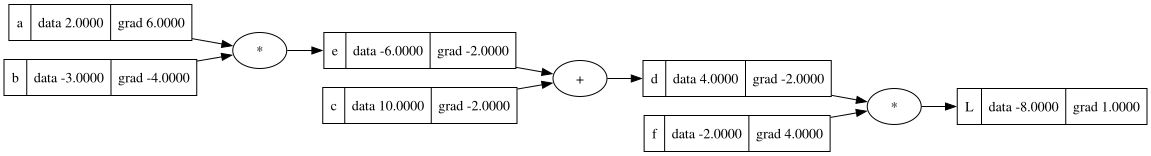

In [79]:
L.backward()
draw_dot(L)

In [80]:
def lol():
  h = 0.0001

  a = Value(2.0, label='a')
  b = Value(-3.0, label='b')
  c = Value(10.0, label='c')
  e = a*b; e.label = 'e'
  d = e + c; d.label = 'd'
  f = Value(-2.0, label='f')
  L = d * f; L.label = 'L'
  L1= L.data

  a = Value(2.0, label='a')
  b = Value(-3.0, label='b')
  c = Value(10.0, label='c')
  e = a*b; e.label = 'e'
  d = e + c; d.label = 'd'
  f = Value(-2.0 + h, label='f')
  L = d * f; L.label = 'L'
  L2 = L.data

  print((L2 - L1) / h)
  
lol()

3.9999999999995595


In [92]:
# inputs
x1 = Value(2.0, label='x1')
x2 = Value(0.0, label='x2')
# weights
w1 = Value(-3.0, label='w1')
w2 = Value(1.0, label='w2')

# bias
b = Value(6.8813735870195432, label='b')

x1w1 = x1*w1; x1w1.label = 'x1*w1'
x2w2 = x2*w2; x2w2.label = 'x2*w2'
x1w1x2w2 = x1w1 + x2w2; x1w1x2w2.label = 'x1*w1 + x2*w2'
n = x1w1x2w2 + b; n.label = 'n'
o = n.tanh(); o.label = 'o'


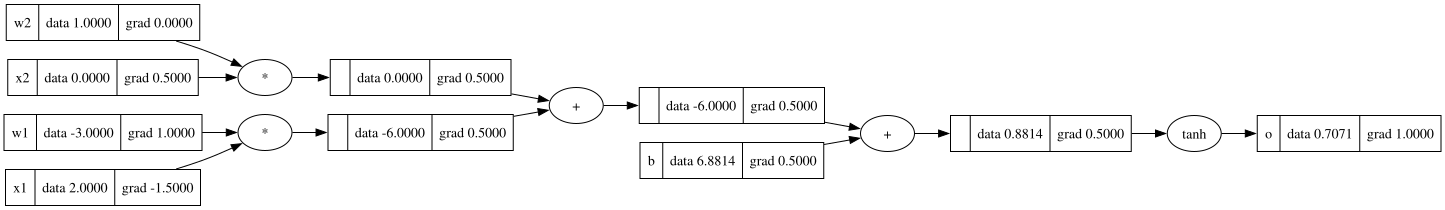

In [91]:
o.backward()
draw_dot(o)

In [ ]:
import random

class Neuron:
  def __init__(self, nin) -> None:
    self.w = [Value(random.uniform(-1,1)) for _ in range(nin)]
    self.b = Value(random.uniform(-1,1))

  def __call__(self, x):
    # w.x + b
    act = sum((wi*xi for wi,xi in zip(self.w, x)), self.b)
    out = act.tanh()
    return out


  def parameters(self):
    return self.w + [self.b]

  def __repr__(self) -> str:
    return f"Neuron(nin={len(self.w)}, w={self.w}, b={self.b})"

class Layer:
  def __init__(self, nin, nout) -> None:
    self.neurons = [Neuron(nin) for _ in range(nout)]

  def __call__(self, x):
    out = [n(x) for n in self.neurons]
    return out[0] if len(out) == 1 else out

  def parameters(self):
    return [p for n in self.neurons for p in n.parameters()]


class MLP:
  def __init__(self, nin, nouts):
    sz = [nin] + nouts
    self.layers = [Layer(sz[i], sz[i+1]) for i in range(len(nouts))]

  def __call__(self, x):
    for layer in self.layers:
      x = layer(x)
    return x

  def parameters(self):
    return [p for layer in self.layers for p in layer.parameters()]

In [100]:
random.seed(42)

# 2 inputs
# 4 hidden
# 1 output

model = MLP(2, [4, 4, 1])
x = [Value(2.0), Value(3.0)]
ypred = model(x)
print(ypred)
print(len(model.parameters()))

# 
ygt = Value(1.0)
loss = (ypred - ygt)**2
loss.backward()
print(loss)
print(ypred.grad)
print(model.parameters()[0].grad)



Value(data=0.9086223274919436)
37
Value(data=0.008349879032989605)
-0.1827553450161128
-1.777908496855709e-05


In [105]:
xs = [
  [2.0, 3.0],
  [-3.0, -1.0],
  [0.5, 1.0],
  [1.0, 1.0],
]
ys = [1.0, -1.0, -1.0, 1.0]

xs = [[Value(v) for v in row] for row in xs]
ys = [Value(v) for v in ys]

for epoch in range(100):
 # 1 forward
 ypred = [model(x) for x in xs]
 loss = sum((ygt - ypred)**2 for ygt, ypred in zip(ys, ypred))

 # 2 clear gradients
 for p in model.parameters():
  p.grad = 0

 # 3 backward + update weights
 loss.backward()
 for p in model.parameters():
  p.data -= 0.05 * p.grad

print(f"Epoch {epoch} loss: {loss.data}")
  

Epoch 99 loss: 0.0050051116758906


In [106]:
x = [2.0, 3.0, -1.0]
n = MLP(3, [4, 4, 1]  )
n(x)


Value(data=-0.015112409056897745)

In [108]:
n.parameters()

[Value(data=0.2370395047284921),
 Value(data=0.7234138006215545),
 Value(data=0.15470429051352408),
 Value(data=0.40914367242984695),
 Value(data=-0.9083512326886756),
 Value(data=-0.5442034486969063),
 Value(data=-0.42122407279578566),
 Value(data=-0.840416046152745),
 Value(data=-0.5344182272779396),
 Value(data=-0.7979971411805418),
 Value(data=-0.44405279377981577),
 Value(data=0.27136888852880037),
 Value(data=-0.2703356420598315),
 Value(data=-0.2596380657662347),
 Value(data=-0.5809859384570246),
 Value(data=-0.4660443559017733),
 Value(data=0.873309175424988),
 Value(data=0.2960707704931871),
 Value(data=0.21826201133397638),
 Value(data=-0.657722703603806),
 Value(data=0.45825359590069836),
 Value(data=-0.6731950124761432),
 Value(data=-0.24108911648470444),
 Value(data=0.9790467012731905),
 Value(data=0.2799995197081857),
 Value(data=0.11389948754929247),
 Value(data=0.3692285019797492),
 Value(data=0.6857038403796192),
 Value(data=0.5519998230924896),
 Value(data=-0.54190385

In [133]:
# 1) 和视频一样的结构：3 维输入
xs = [
  [2.0, 3.0, -1.0],
  [3.0, -1.0, 0.5],
  [0.5, 1.0, 1.0],
  [1.0, 1.0, -1.0],
]
ys = [1.0, -1.0, -1.0, 1.0]

n = MLP(3, [4, 4, 1])

In [135]:
# 2) 前向 + loss
ypred = [n(x) for x in xs]
ypred

[Value(data=0.5781771521066059),
 Value(data=0.4737386672425181),
 Value(data=0.3681650551635941),
 Value(data=0.5655484651801773)]

In [136]:
loss = sum((yout - ygt)**2 for ygt, yout in zip(ys, ypred))
loss

Value(data=4.410463928608747)

In [143]:
# 3) 反传，看某一个具体参数

loss.backward()
print(n.layers[0].neurons[0].w[0].grad) #梯度
print(n.layers[0].neurons[0].w[0].data) # 当前值


-4.844117971948704
0.09435663398909933


In [144]:

# 4) 手动走一步梯度下降（视频里正在写的）
for p in n.parameters():
  p.data += -0.01 * p.grad   # 或 p.data -= 0.01 * p.grad

In [145]:
# 5) 再算一遍 loss，应该变小
ypred = [n(x) for x in xs]
loss = sum((yout - ygt)**2 for ygt, yout in zip(ys, ypred))
print("改之后 loss", loss.data)

改之后 loss 1.80232054953244


In [146]:
import random
random.seed(42)

xs = [
  [2.0, 3.0, -1.0],
  [3.0, -1.0, 0.5],
  [0.5, 1.0, 1.0],
  [1.0, 1.0, -1.0],
]
ys = [1.0, -1.0, -1.0, 1.0]

n = MLP(3, [4, 4, 1])

for k in range(20):                      # 重复 20 次「手动那一步」
  # 1) 前向 + loss
  ypred = [n(x) for x in xs]
  loss = sum((yout - ygt)**2 for ygt, yout in zip(ys, ypred))

  # 2) 清零（从第 2 次起必须有；每次都写最安全）
  for p in n.parameters():
    p.grad = 0

  # 3) 反传
  loss.backward()

  # 4) 更新
  for p in n.parameters():
    p.data -= 0.05 * p.grad

  print(k, loss.data)

0 5.230517512042234
1 2.7046890507642445
2 1.8460237252314982
3 1.1774870087919076
4 0.8217294550832639
5 0.5957215587693913
6 0.43115794091632775
7 0.3468314917603138
8 0.28903713992681357
9 0.24605065583938185
10 0.2130938981393669
11 0.18718814718937848
12 0.16638755353165724
13 0.14937997337031508
14 0.13525484661841905
15 0.12336389545940175
16 0.11323493741060493
17 0.10451700918771245
18 0.09694449026136831
19 0.09031307448189847
